In [ ]:
# Create a loading plot based on results from PCA
#    David H. Nguyen, PhD | Tissue Spatial Geometrics Lab

# Instructions
# 1. The input csv file should be formatted as in the below image. This script was meant to work with the csv file outputted by the following scripts,
#    which has the suffix "_loading_plot_data.csv": 
#     a. "PCA_Biplot_ScreePlot_for DCI and PCI Matrices.ipynb"
#     b. "PCA_MEDIAN-Standardization_for LCPC FFT DATA_Export Loadings.ipynb" 
# 2. You have to type in information at Step 2 (which columns you want to graph) and Step 3 (which range of values to exclude).


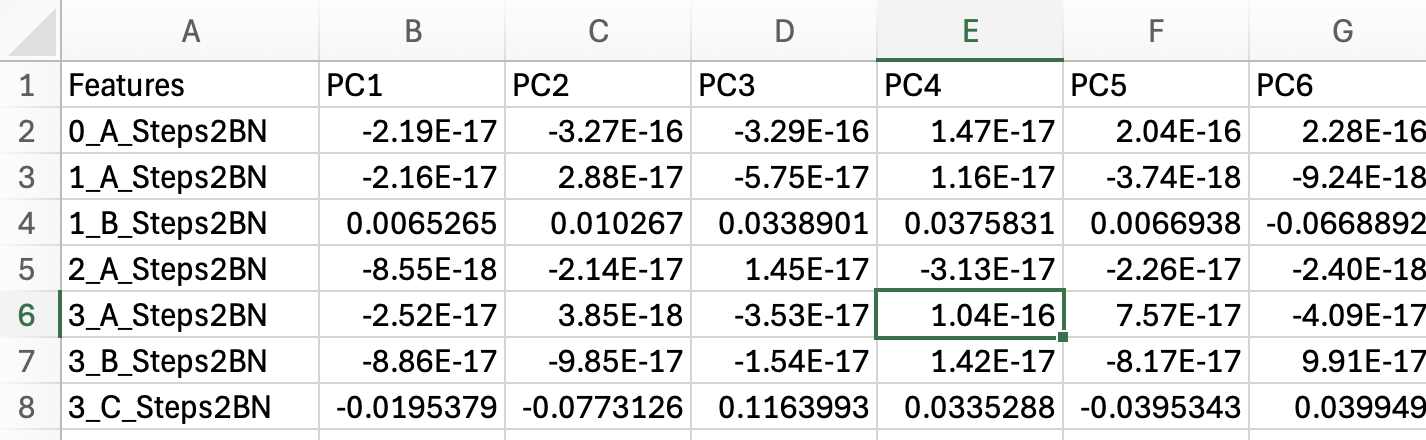

In [ ]:
# Load the dependencies
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Step 1. Paste in the file path to the csv file
file_path = 'FilePathtoCSVfile'
df = pd.read_csv(file_path)
df.head()

In [ ]:
# Step 2. Type in the name of the columns that you want to be the x-axis or the y-axis.
x_pc = 'PC1'
y_pc = 'PC2'

# Step 3. This lets you erase clutter by EXCLUDING features that will be graphed. 
#    Type in the upper and lower bounds of each axis that you want EXCLUDED from the graph. This is the middle cluttered region.
x_super_low = -100 # The arbitrary default is -100
x_low = -0.001 # the default setting is  -0.001 to exclude only a very narrow range for x<0
x_high = 0.001 # the default setting is  0.001 to exclude only a very narrow range for x>0
x_super_high = 100 # # The arbitrary default is 100

y_super_low = -100 # # The arbitrary default is -100
y_low = -0.001 # the default setting is  -0.001 to exclude only a very narrow range y<0
y_high = 0.001 #t he default setting is  0.001 to exclude only a very narrow range for y>0
y_super_high = 100 # # The arbitrary default is 100


In [ ]:
# Step 4. Create the loading plot

def plot_loadings_filtered(x_pc, y_pc,
                           x_super_low, x_low, x_high, x_super_high,
                           y_super_low, y_low, y_high, y_super_high):

    # Check columns exist
    for col in [x_pc, y_pc]:
        if col not in df.columns:
            raise ValueError(f"Column '{col}' not found. Available: {list(df.columns)}")

    # ---------------- X-axis keep regions ----------------
    x_keep = (
        ((df[x_pc] >= x_super_low) & (df[x_pc] < x_low)) |
        ((df[x_pc] > x_high) & (df[x_pc] <= x_super_high))
    )

    # ---------------- Y-axis keep regions ----------------
    y_keep = (
        ((df[y_pc] >= y_super_low) & (df[y_pc] < y_low)) |
        ((df[y_pc] > y_high) & (df[y_pc] <= y_super_high))
    )

    # Combine filters
    filtered_df = df[x_keep & y_keep]

    print(f"Plotting {len(filtered_df)} / {len(df)} features after filtering")

    # ---------------- PLOT ----------------
    plt.figure(figsize=(8, 6))

    for i in range(filtered_df.shape[0]):
        x = filtered_df.iloc[i][x_pc]
        y = filtered_df.iloc[i][y_pc]
        feature = filtered_df.iloc[i]["Features"]

        plt.arrow(0, 0, x, y,
                  color="red",
                  alpha=0.5,
                  head_width=0.001)

        plt.text(x * 1.1, y * 1.1, feature, color="red", fontsize=8)

    plt.xlabel(x_pc)
    plt.ylabel(y_pc)
    plt.title(f"Loading Plot: {x_pc} vs {y_pc} (Filtered)")
    plt.axhline(0, color="gray", lw=1)
    plt.axvline(0, color="gray", lw=1)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# ---------------- RUN ----------------
plot_loadings_filtered(
    x_pc, y_pc,
    x_super_low, x_low, x_high, x_super_high,
    y_super_low, y_low, y_high, y_super_high
)